# φ2 Hamiltonian Truncation on a Circle

Builds the truncated Hamiltonian for an interacting scalar field in 1+1D on a circle of radius $r$:

$$H_\text{eff} = H_0 + \frac{g}{24} H_4$$


and studies how the energy gap $E_1^+ - E_0$ converges as the energy cutoff $E_\mathrm{max}\to\infty$.

Reference: arXiv:2507.15941


In [ ]:
import math

import numpy as np
import scipy.sparse as sp

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from collections import Counter
import csv

%matplotlib inline

## 1. Single-particle energy and mode indexing

Modes are labelled by magnitude $l \ge 0$ (momentum $\pm l/r$) and sign $\sigma = \pm 1$.
States are stored as dictionaries `{...,-l₂:n₂₋,-l₁:n₁₋,l₀:n₀,l₁:n₁₊,l₂:n₂₊,...}`.


In [2]:
def omega(l, mQ, r):
    # State Energy
    return math.sqrt(float(l)*float(l)/(r*r) + mQ*mQ)

def gen_omega_list(lmax, mQ, r):
    # Global variable storing a list of all state energies.
    global omega_list
    omega_list = [omega(abs(l), mQ, r) for l in range(0,lmax+1)]

# --- Helper functions ---
def get_total_occupation_number(state):
    # Returns occupation number for a given state in dictionary format.
    return sum(state.values())


def convert_state_to_list(state, lmax):
    # Returns state held in dictionary to list.
    return [state.get(i, 0) for i in range(-lmax, lmax+1)]

def get_state_energy(state, mQ, r):
    # Returns state energy for state in dictionary format.
    return sum([nl*omega(l, mQ, r) for l, nl in state.items()])

## 2. Basis generation via the change problem

The change problem is essentially how many ways can you make change for some quantity given a set of coins. Here we have any angular momentum state.

`gen_coins` builds a dictionary with all of the ways to create a number by summing smaller numbers. This is stored in the global state `coins` and will allow us to automatically build states in the **zero-total-momentum** sector (`l_total == 0`).
Elements of the `coins` dictionary appear as e.g. `{5:[[5],[4,1],[3,2],[3,1,1],[2,1,1,1],[1,1,1,1,1]}`.

`coin_dict` then turns the global dictionary `coins` into a global frequency dictionary `coinDict`. Elements of `coinDict` appear as, e.g. `{5:[Counter({4:1}),Counter({3:1,1:1}),Counter({2:2},Counter({2:1,1:2}),Counter({1:4})}`. 

`coin_energies` computes a list of energies for each set of coins labelled by `l` in `coins`. As positive and negative `l` states have the same energy, this only needs computing once.



In [3]:
def gen_coinDict(coins):
    #Turns coins into a global counting dictionary, which is easier to perform operations on.
    global coinDict
    coinDict = {}
    for key in coins.keys():
        coinDict[key] = [Counter(val) for val in coins[key]]
        

def gen_coins(n_max):
    global coins
    # Creates the coins dictionary if it does not already exist.
    if 'coins' not in globals():
        coins = {}
        coins.setdefault(1,[[1]]) 
        
    # If we have already calculated up to n_max, just return the dictionary.
    if n_max in coins: return(coins)
     

    for i in range(max(coins.keys())+1,n_max+1):
        #This step is a little complicated so I'll break it down into the two parts of the sum:
        #   1. The first part adds [1] to the end of every list for the previous element (e.g. 6:[[6],...] -> 7:[...,[6, 1],...])
        #   2. The second part adds 1 to the final element of the previous interation (e.g. 6:[...,[3,2,1],...]->7:[...,[3,2,2],...]) given the following conditions:
        #       a) If the length of the dictionary is 1, just add one (i.e 6:[[6],..] -> 7:[[7],...])
        #       b) If the final two elements of a list are the same, there also exists one where the final two elements differ by two (e.g. 6:[...,[3,3],[4,2],...]).
        #          Without input, this would result in duplicate entries. Therefore, the final two elements must not be equal for this step.

        coins[i] = [cns[:-1]+[cns[-1]+1] for cns in coins[i-1] if (len(cns)==1 or cns[-2]!=cns[-1])] + list(map(lambda x:x+[1], coins[i-1])) 
        coins[i] = sorted(coins[i], key=len) #Not sure this helps. But re-ordering the coin dictionary after creation in terms of occupation number.
        
    # Creating a counting dictionary version of this as it is easier to perform operations on.
    gen_coinDict(coins)
    return coins


def coin_energies(l,mQ,r):
    #Computes the energies of each possible change.
    return [sum(map(lambda c: omega(c, mQ, r), change)) for change in coins[l]]
            

In [4]:
#Example of the coins. 
gen_coins(4)
#Just printing states 3 and 4.
for i in range(3,5):
    print(f'lmax = {i}')
    for change in coins[i]:
        print(f'Coins = {change}, Energy = {sum(map(lambda c: omega(c, 1, 1), change))}')

lmax = 3
Coins = [3], Energy = 3.1622776601683795
Coins = [2, 1], Energy = 3.6502815398728847
Coins = [1, 1, 1], Energy = 4.242640687119286
lmax = 4
Coins = [4], Energy = 4.123105625617661
Coins = [2, 2], Energy = 4.47213595499958
Coins = [3, 1], Energy = 4.576491222541475
Coins = [2, 1, 1], Energy = 5.06449510224598
Coins = [1, 1, 1, 1], Energy = 5.656854249492381


## Generating the set of basis states

`gen_basis` builds all occupation-number states with energy ≤ `e_max`, by `l` iterating up to `lmax` and each time merging two `coinDicts` together (one with negative angular momentum). Zero momentum states are then added up to `e_max`. This produces all ways to build states with `l_total == 0`.

In [ ]:
def gen_reduced_basis(lmax, e_max, mQ, r):
    asymList = []

    #l=0:
    result = [Counter({0: i}) for i in range(0, int(math.floor(e_max/mQ)) + 1)]    
    #l>0:
    for l in range(1,lmax+1):
        gen_coins(l) # All ways of making up to lmax with smaller numbers
        gen_coinDict(coins)
        coinEnergies = coin_energies(l,mQ,r)

        # Iterate through positive (ii, ci) and negative (jj, cj) momenta, then merge dictionaries.
        for ii,ci in enumerate(coinDict[l]):
            for jj,cj in enumerate(coinDict[l]):
                if jj>=ii: # Only make one copy of each asymmetric state.

                    #Build a temporary energy for the state so we can 
                    # A) figure out if it exceeds e_max.
                    # B) add l=0 states successively up to e_max.
                    e_temp = e_max - coinEnergies[ii] - coinEnergies[jj]
                    
                    if e_temp > 0: #Fill up l=0 state up to e_max.

                        # Merge positive and negative l states, with total l=0.
                        negative_ci = {-jjj:cjj for jjj,cjj in cj.items()}
                        # Adding successively more l=0 states up to e_max in the center of the dictionary.
                        result += [Counter( negative_ci | ci )]
                        result += [Counter( negative_ci | {0:i} | ci ) for i in range(1, int(math.floor(e_temp/mQ)) + 1)]

                
    return (result, asymList)

In [ ]:
def convertBasis(reduced_basis, dupList):
    new_basis = reduced_basis.copy(); runner = 1
    for ix in sorted(dupList):
        new_basis.insert(ix+runner,Counter({-l:nl for l, nl in reduced_basis[ix].items()}))
        runner += 1
        
    return new_basis

def conversionDictionary(basis_len, dupList):
    cD = {}; runner=0
    for ix in range(basis_len+len(dupList)):
        cD[ix] = ix+runner
        if ix in dupList: runner+=1
    return cD

In [7]:
#Helper function which calculates the maximum angular momentum pairs which can be produced, still below e_max.
def effective_lmax(lmax, e_max, mQ, r):
    if mQ**2 < e_max**2 / 4:
        return int(min(lmax, math.floor(math.sqrt(max(0, r**2*(e_max**2/4 - mQ**2))))))
    return 0

## 3. Basis Generation Timing Between 2110.08273 Method and New Method

Must compute the timing with 2110.08237 in a different notebook and import as "benchmark_basisgen_results.csv"

In [31]:
# Hamiltonian Parameters.
mQ = 1; r = 10/(2*math.pi) 

# Lists to hold the timing result and basis lengths.
execution_times = []; len_basis = []
emax_list = range(6,20) #Test Range of E_max.

# 1. Iterate over emax_list
for emax in emax_list:
    print(f"E_max: {emax}")
    lmaxeff = effective_lmax(emax,emax,mQ,r)
    
    # Using timeit to get accurate generation timings.
    duration = %timeit -o gen_reduced_basis(lmaxeff,emax,mQ,r)
    # Generating the basis via the above method so we can find it's length.
    basis = gen_reduced_basis(lmaxeff,emax,mQ,r)
    
    # Adding execution timings and basis length to the result.
    execution_times.append(duration.average)
    len_basis.append(len(basis))
    
    del coins #For fairness, reset the coins dictionary each time.
    
    

# 2. Importing comparison timings. This file is produced from the code of https://arxiv.org/abs/2110.08273 and imported here.
csv_filename = "benchmark_basisgen_results.csv"
execution_times_prev = []; emax_list_prev = []
with open(csv_filename, mode="r") as file:
    reader = csv.reader(file)
    
    # Prints Hamiltonian parameters for benchmark. Confirm that these are the same in-use here!
    print('--- Benchmark Params ---')
    print(''.join(next(reader)))
    
    # Skips header for e_max list.
    next(reader) 
    emax_list_prev = list(map(float,next(reader))) #Saves e_max list and converts to float.
    
    next(reader)  # And skips Header for result array.
    for row in reader:
        execution_times_prev.append(float(row[1])) # Convert time back to float

# 3. Plot the results
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel(r'$E_\text{max}$', color='black')
ax1.set_ylabel('Time in Seconds (Log Scale)')
ax1.set_yscale('log')
ax1.tick_params(axis='x', labelcolor='black')
ax1.grid(True, which="both", linestyle='--', alpha=0.5)


ax1.plot(emax_list, execution_times, marker='o', linestyle='-', color='b', label='New Method')
ax1.plot(emax_list_prev, execution_times_prev, marker ='o', linestyle='-', color='r', label='2110.08273 Method')

# 4. First degree polynomial fit to the timing data.
coef_new = (np.polyfit(emax_list, np.log10(execution_times), 1))
coef_old = (np.polyfit(emax_list_prev, np.log10(execution_times_prev), 1))
poly_new = np.poly1d(coef_new)
poly_old = np.poly1d(coef_old)
xs = np.linspace(emax_list[1],emax_list[-1])

ax1.plot(xs, 10**poly_new(xs), linestyle='--', color='b', label=f'New Fit $log(t)={coef_new[0]:.1f}x+{coef_new[1]:.1f}$')
ax1.plot(xs, 10**poly_old(xs), linestyle='--', color='r', label=f'2110.08273 Fit $log(t)={coef_old[0]:.1f}x+{coef_old[1]:.1f}$')
ax1.legend()

# --- A second x-axis to show the basis length. 
ax2 = ax1.twiny() 
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(emax_list) 

formatted_top_labels = []
for x in len_basis:
    if x>10000:# Cleaning up long numbers into standard form.
        base, exponent = f"{x:.0e}".split("e")
        # Clean up the sign on the exponent (e.g., +06 becomes 6)
        exponent = int(exponent) 
        # Wrap in LaTeX math style for superscripts
        formatted_top_labels.append(f"${base} \\times 10^{{{exponent}}}$")
    else:
        # Otherwise using the original number.
        formatted_top_labels.append(x)
    
ax2.set_xticklabels(formatted_top_labels) 
ax2.set_xlabel('Basis Length', color='blue')
ax2.tick_params(axis='x', labelcolor='blue')


plt.title(r'Basis Generation Time vs $E_\text{max}$')
plt.show()


E_max: 6
52.2 μs ± 774 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
E_max: 7


KeyboardInterrupt: 

## 3. State Occupation Plot

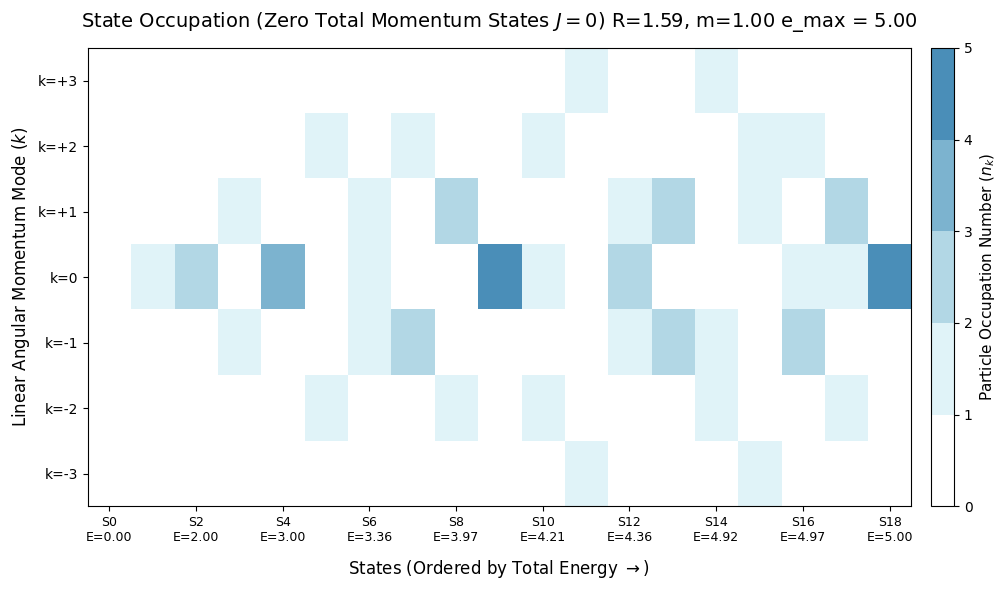

In [17]:
# Hamiltonian Truncation Perameters.
mQ = 1; r = 10/(2*math.pi); e_max=5; lmaxeff = effective_lmax(e_max,e_max,mQ,r)

# Generate the basis.
reduced_basis, asymList = gen_reduced_basis(lmaxeff,e_max,mQ,r)

basis = convertBasis(reduced_basis,asymList)
# Possible Angular Momenta
modes = list(range(-lmaxeff, lmaxeff+1))


# --- Sort states by energies (E = sum(sqrt(1 + k^2))) ---
sorted_states = []
# Computing the energies
state_energies = []
for state in basis:
    state_energies.append(sum([nl*omega(l, mQ, r) for l, nl in state.items()]))

# Sorting the states by energy.
sorted_states=[x for x, _ in sorted(zip(basis, state_energies), key=lambda pair: pair[1])]
sorted_energies=sorted(state_energies)

# --- Construct the Grid of Angular Momenta on the y-axis with States of Increasing Energies on x-axis ---
grid_matrix = np.zeros((len(modes), len(sorted_states)))
for col_idx, stateDict in enumerate(sorted_states):
    grid_matrix[:, col_idx] = [stateDict[x] if x in stateDict else 0 for x in modes]


# --- Plotting the Grid Heatmap ---
fig, ax = plt.subplots(figsize=(11, 6))

#DISCRETE COLOUR MAP for the plot. Add more colours if more than 10 occupation number required.:
blue_gradient = [
    '#ffffff', '#e0f3f8', '#b2d7e5', '#7cb3cf', '#4a8eb8',
    '#2367a0', '#0e457f', '#022659', '#001035', '#000314'
]
blue_cmap = ListedColormap(blue_gradient[:int(max(np.ndarray.flatten(grid_matrix)))])
# origin='lower' keeps negative momentum at the bottom and positive at the top
cax = ax.imshow(grid_matrix, cmap=blue_cmap, aspect='auto', origin='lower',interpolation='nearest')

# Axis Configuration (Y-Axis: Momentum)
mode_labels = [f"k={m}" if m <= 0 else f"k=+{m}" for m in modes] # Separating positive and negative angular momenta.
ax.set_yticks(np.arange(len(modes)))
ax.set_yticklabels(mode_labels, fontsize=10)
ax.set_ylabel("Linear Angular Momentum Mode ($k$)", fontsize=12)

# Axis Configuration (X-Axis: Energy Sorted States)
state_labels = [f"S{i}\nE={item:.2f}" for i, item in enumerate(sorted_energies)]
if len(state_labels)>15:
    # Reducing the number of state labels if it becomes too large, as unreadable.
    _state_labels=state_labels[::int(math.ceil(len(state_labels)/15))]
    ax.set_xticks(np.arange(0,len(sorted_states),int(math.ceil(len(state_labels)/15))))
    ax.set_xticklabels(_state_labels, fontsize=9)

else:
    ax.set_xticks(np.arange(0,len(sorted_states)))
    ax.set_xticklabels(state_labels, fontsize=9)

ax.set_xlabel("States (Ordered by Total Energy $\\rightarrow$)", fontsize=12, labelpad=10)

ax.set_title(f"State Occupation (Zero Total Momentum States $J=0$) R={r:.2f}, m={mQ:.2f} e_max = {e_max:.2f}", fontsize=14, pad=15)

# Setup a clean discrete colorbar for occupation levels
max_occ = int(np.max(grid_matrix))
cbar = fig.colorbar(cax, ax=ax, ticks=np.arange(max_occ + 1), pad=0.02)
cbar.set_label('Particle Occupation Number ($n_k$)', fontsize=11)

plt.grid(False) # Turn off the default global grid overlay to keep image clean
plt.tight_layout()
plt.show()

## 4. Raising and lowering operations.
The following functions take two states, ordered in energy, and computes matrix element for their transition amplitude. The functions are classified by Hamming Distance.

- `phi4_hd0` — adds and removes one particle from the state.
- `phi2_hd2` — removes two particles with opposite angular momentum.


The correct symmetry factor is computed following arXiv:2507.15941 Eqs. (2.5)–(2.7).

In [18]:
def phi4_hd0(st):
    # --- One raising and one lowering operator applied to the same state.
    return 2*sum([(st[l]*st[l]-1)/omega_list[abs(l)]**2 for l in st.keys()])


def phi2_hd2(stA, stB):
    # --- Hamming distance 2 between states A and B. Must be energy ordered.
    for l in stA.keys():
        if (stA[l] - stB[l]) != 0:
            # Checks if it is simply reducing the l=0 state.
            if l==0:
                return math.sqrt(stA[0]*(stA[0]-1)) * (1/omega_list[0]) 
            # Otherwise will compute transition element for removing l!=0 state.
            if (stA[-l] - stB[-l]) != 0: 
                return 2*math.sqrt(stA[l]*stA[-l]) / (omega_list[abs(l)])
            
            else: return 0 


In [19]:
def falling_factorial(x,k):
    return math.prod(x - i for i in range(k))

def raising_factorial(x,k):
    return math.prod(x + i for i in range(k))

## 5. Transition Matrix by Hamming Distance 

Just considering `H_eff = H₀ + (m2/2)·H4`.

In [20]:
def basis_even(basis, asymList):  
    even_states = []; even_asymList = []
    for ix, s in enumerate(basis):
        if sum(s.values()) % 2 == 0:
            even_states += [s]
            if ix in asymList: even_asymList+=[len(even_states)-1]
    return (even_states, even_asymList)

def basis_odd(basis):   return [s for s in basis if sum(s.values()) % 2 != 0] # Collects only odd basis states.

In [ ]:
# NOTE Input states and energies MUST first be sorted by occupation number, followed by energy.
def transition_matrix_phi4(g, sorted_basis, sorted_energies, boundaries, occupation_numbers, asymList, lmaxeff):
    hashable_basis = {frozenset(Counter()):0}

    # Index conversion helper.
    cD = conversionDictionary(len(sorted_basis), asymList)

    # phi2 Coupling
    cphi4=g/24

    # --- Now iterating over all zero or two Hamming Distance states. ---
    H_eff = []; cols = []; rows = []
    
    # This dictionary is to keep track of how many times a state of momentum l has been removed from a block of given occupation number.
    running_iy0=Counter()
    running_iy2=Counter()
    running_iy4=Counter()


    # Iterate over states
    for ix, state in enumerate(sorted_basis):
        hashable_basis[frozenset(state.items())] = ix
        

        # Ignore the zero state.
        if ix>0:
            ixasym=False
            if ix in asymList: ixasym=True


            # --- Zero Difference in Occupation Number ---
            
            # Hit the Diagonal. First with the \phi^2 operator, then with the state energy.
            H_eff.extend([(cphi4) * phi4_hd0(state) + sorted_energies[ix]])
            rows.extend([cD[ix]]); cols.extend([cD[ix]])

            if ixasym: H_eff.extend([(cphi4) * phi4_hd0(state) + sorted_energies[ix]]); rows.extend([cD[ix]+1]); cols.extend([cD[ix]+1])
            

            
            # --- Two Difference in Occupation Number ---

            # First calculating result from removing & adding each state:
            _tempaddremove = {ll: nll * 1/ omega_list[ll] for ll, nll, in state.items()}
            
            
            # This allows us to jump to the next boundary when the current state has two fewer occupants than the previous state.
            lower_bound_0 = boundaries[occupation_numbers[ix]]
            lower_bound_2 = boundaries[occupation_numbers[ix]-2]

                
            # All options here first begin removing two occupants from the state so beginning with this.
            for l, nl in state.items():
                for ll, nll in state.items():
                    if ll>=l and abs(l+ll)<=lmaxeff: # Avoid double-counting and encountering unreachable states (REVISE).

                        remStatePair = Counter({l:1})
                        remStatePair[ll]+=1
                        if not all([state[key]-remStatePair[key]>=0 for key in remStatePair.keys()]): continue

                        # --- Remove three and add one states ---

                        if l+ll == 0:
                            iy = max(lower_bound_2,running_iy2[(l, ll)])
                            res=1
                            
                            # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).
                            H_eff.extend([res, res])
                            cols.extend([cD[ix], cD[iy]]); rows.extend([cD[iy], cD[ix]])

                            if ixasym:
                                if iy in asymList:
                                    H_eff.extend([res, res])
                                    cols.extend([cD[ix]+1, cD[iy]+1]); rows.extend([cD[iy]+1, cD[ix]+1])    
                                else:                                
                                    H_eff.extend([res, res])
                                    cols.extend([cD[ix], cD[iy]+1]); rows.extend([cD[iy]+1, cD[ix]])

                            
                            running_iy2[(l, ll)] = iy + 1 
                            

                                            
                        for lll, nlll, in state.items():
                            remStateTriple = remStatePair.copy()
                            remStateTriple[lll]+=1
                            if not (state[lll] - remStateTriple[lll])>=0: continue

                            if lll>=ll:

                                
                                # ---- Raise 1 low 3 operations ----  
                                if  occupation_numbers[ix]>=2 and (l+ll != 0 and l+lll != 0 and ll+lll !=0): 

                                    new_dict = Counter(state.copy() - remStateTriple.copy() + Counter({(l+ll+lll):1}))
                                    
                                    try:
                                        iy = hashable_basis[frozenset(new_dict.items())]
                                        
                                        res=1
                                        # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).
                                        H_eff.extend([res, res])
                                        cols.extend([cD[ix], cD[iy]]); rows.extend([cD[iy], cD[ix]])



                                        if ixasym: 
                                            # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).
                                            res=1
                                            
                                            if iy in asymList: 
                                                H_eff.extend([res, res])
                                                cols.extend([cD[ix]+1, cD[iy]+1]); rows.extend([cD[iy]+1, cD[ix]+1])
                                            else: 
                                                H_eff.extend([res, res])
                                                cols.extend([cD[ix]+1, cD[iy]]); rows.extend([cD[iy], cD[ix]+1]) 
    

                                        elif iy in asymList:
                                            H_eff.extend([res, res])
                                            cols.extend([cD[ix], cD[iy]+1]); rows.extend([cD[iy]+1, cD[ix]])       
     


                                    except KeyError:
                                        if ixasym:
                                            symmetrised = Counter({-key:value for key,value in reversed(new_dict.items())})
                                            iy = hashable_basis[frozenset(symmetrised.items())]
                                            

                                        if iy in asymList and ixasym:
                                            res=0
                                            H_eff.extend([res, res, res, res])
                                            cols.extend([cD[ix]+1, cD[iy], cD[ix], cD[iy]+1]); rows.extend([cD[iy], cD[ix]+1, cD[iy]+1, cD[ix]])

                                    


                                # ---- Four lowering operations ----
                                if  occupation_numbers[ix]>=4:           
                                    # This allows us to jump to the next boundary when the current state has four fewer occupants than the previous state.
                                    lower_bound_4 = boundaries[occupation_numbers[ix]-4]
                                    if -(l+ll+lll)<lll: continue 


                                    if state[-(l+ll+lll)]-remStateTriple[-(l+ll+lll)]>0: 
                                        remStateTriple[-(l+ll+lll)]+=1
                                            
                                        res = (cphi4) * math.sqrt(nl*nll*nlll*(state[-(l+ll+lll)])) / (omega_list[abs(l)] * omega_list[abs(ll)] * omega_list[abs(lll)] * omega_list[abs(l+ll+lll)])
                                        res=1
                                        iy = max(lower_bound_4, running_iy4[tuple(remStateTriple.keys())])

                                        # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).
                                        H_eff.extend([res, res])
                                        cols.extend([cD[ix], cD[iy]]); rows.extend([cD[iy], cD[ix]])

                                        running_iy4[tuple(remStateTriple.keys())]=iy+1
                                        
                                        if ixasym: 
                                            H_eff.extend([res, res])
                                            cols.extend([cD[ix]+1, cD[iy]]); rows.extend([cD[iy], cD[ix]+1])
                                            
                                        if iy in asymList:
                                            H_eff.extend([res, res])
                                            cols.extend([cD[ix], cD[iy]+1]); rows.extend([cD[iy]+1, cD[ix]])
                                
                    

                        # --- Zero Difference in Occupation Number ---
                        # ---- 2 raising 2 lowering operations ----

                        result = cphi4 * np.sqrt(nl*nll/(omega_list[ll]*omega_list[l]))

                        if abs(ll-l)>1:
                            iteration = math.ceil((abs(ll-l)+1)/2) if -ll!=l else abs(ll)+1 
                            
                            
                            for i in reversed(range(1, iteration)):
                                stA = l+i; stB = ll-i
                                
                                if (stA == stB == 0 !=l) or (stA != -ll or stB != -l): #MAY BE REDUNDANT NOW.
                                    #print(f'ix={ix},l={l},ll={ll},stA={stA},stB={stB}')
                                    marked = (ll, l, stA, stB)
                                    
                                    iy_min = max(lower_bound_0, running_iy0[marked])
                                    iy_max = ix

                                    new_dict = Counter(state.copy() - remStatePair + Counter({stA:1}) + Counter({stB:1}))
                                    
                                    try:
                                        iy = hashable_basis[frozenset(new_dict.items())]

                                        res = result * np.sqrt(1/(omega_list[stA]*omega_list[stB]))
                                            
                                        res=1
                                        # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).
                                        H_eff.extend([res, res])
                                        cols.extend([cD[ix], cD[iy]]); rows.extend([cD[iy], cD[ix]])
                                        

                                        if ixasym: 
                                            # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).
                                            res=1
                                            
                                            if iy in asymList: 
                                                
                                                H_eff.extend([res, res])
                                                cols.extend([cD[ix]+1, cD[iy]+1]); rows.extend([cD[iy]+1, cD[ix]+1])
                                            else: 
                                                H_eff.extend([res, res])
                                                cols.extend([cD[ix]+1, cD[iy]]); rows.extend([cD[iy], cD[ix]+1]) 
                                            running_iy0[marked] = iy + 1  

                                        elif iy in asymList:
                                            H_eff.extend([res, res])
                                            cols.extend([cD[ix], cD[iy]+1]); rows.extend([cD[iy]+1, cD[ix]])    

                                            running_iy0[marked] = iy + 1              

                                    except KeyError:
                                        if ixasym:
                                            symmetrised = Counter({-key:value for key,value in new_dict.items()})
                                            iy = hashable_basis[frozenset(symmetrised.items())]


                                        if iy in asymList and ixasym:
                                            res=1
                                            H_eff.extend([res, res, res, res])
                                            cols.extend([cD[ix]+1, cD[iy],cD[ix], cD[iy]+1]); rows.extend([cD[iy], cD[ix]+1,cD[iy]+1, cD[ix]])

                                            running_iy0[(-l,-ll,-stB,-stA)] = iy + 1 

                                    

                                        

                                   
                
    # Convert to sparse matrix format.
    H_eff = np.array(H_eff); rows = np.array(rows); cols = np.array(cols)

    return sp.coo_matrix((H_eff,(rows, cols)), shape=(len(sorted_basis)+len(asymList),len(sorted_basis)+len(asymList)))

In [282]:
# NOTE Input states and energies MUST first be sorted by occupation number, followed by energy.
def transition_matrix_phi4(g, sorted_basis, sorted_energies, boundaries, occupation_numbers, asymList, lmaxeff):
    hashable_basis = {frozenset(Counter()):0}

    # Index conversion helper.
    cD = conversionDictionary(len(sorted_basis), asymList)

    # phi2 Coupling
    cphi4=g/24

    # --- Now iterating over all zero or two Hamming Distance states. ---
    H_eff = []; cols = []; rows = []
   

    # Iterate over states
    for ix, state in enumerate(sorted_basis):

        # Build a hashable basis over time (you can only look backwards anyway.)
        hashable_basis[frozenset(state.items())] = ix
        

        # Ignore the zero state.
        if ix>0:
            ixasym=False
            if ix in asymList: ixasym=True


            # --- Zero Difference in Occupation Number ---
            
            # Hit the Diagonal. First with the \phi^2 operator, then with the state energy.
            H_eff.extend([(cphi4) * phi4_hd0(state) + sorted_energies[ix]])
            rows.extend([cD[ix]]); cols.extend([cD[ix]])

            if ixasym: H_eff.extend([(cphi4) * phi4_hd0(state) + sorted_energies[ix]]); rows.extend([cD[ix]+1]); cols.extend([cD[ix]+1])
            

            
                
            # All options here first begin removing two occupants from the state so beginning with this.
            for l, nl in state.items():
                for ll, nll in state.items():
                    if ll>=l and abs(l+ll)<=lmaxeff: # Avoid double-counting and encountering unreachable states (REVISE).

                        remStatePair = Counter({l:1})
                        remStatePair[ll]+=1
                        if not all([state[key]-remStatePair[key]>=0 for key in remStatePair.keys()]): continue

                        # --- Remove three and add one states ---

                        if l+ll == 0:
                            new_dict = state.copy() - remStatePair.copy()
                            iy = hashable_basis[frozenset(new_dict.items())]
                            res=1
                            
                            # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).
                            H_eff.extend([res, res])
                            cols.extend([cD[ix], cD[iy]]); rows.extend([cD[iy], cD[ix]])

                            if ixasym:
                                if iy in asymList:
                                    H_eff.extend([res, res])
                                    cols.extend([cD[ix]+1, cD[iy]+1]); rows.extend([cD[iy]+1, cD[ix]+1])    
                                else:                                
                                    H_eff.extend([res, res])
                                    cols.extend([cD[ix], cD[iy]+1]); rows.extend([cD[iy]+1, cD[ix]])

                            
                            

                                            
                        for lll, nlll, in state.items():
                            remStateTriple = remStatePair.copy()
                            remStateTriple[lll]+=1
                            if not (state[lll] - remStateTriple[lll])>=0: continue

                            if lll>=ll:

                                
                                # ---- Raise 1 low 3 operations ----  
                                if  occupation_numbers[ix]>=2 and (l+ll != 0 and l+lll != 0 and ll+lll !=0): 

                                    new_dict = state.copy() - remStateTriple.copy() + Counter({(l+ll+lll):1}) 
                                    
                                    try:
                                        iy = hashable_basis[frozenset(new_dict.items())]
                                        
                                        res=1
                                        # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).
                                        H_eff.extend([res, res])
                                        cols.extend([cD[ix], cD[iy]]); rows.extend([cD[iy], cD[ix]])



                                        if ixasym: 
                                            # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).
                                            res=1
                                            
                                            if iy in asymList: 
                                                H_eff.extend([res, res])
                                                cols.extend([cD[ix]+1, cD[iy]+1]); rows.extend([cD[iy]+1, cD[ix]+1])
                                            else: 
                                                H_eff.extend([res, res])
                                                cols.extend([cD[ix]+1, cD[iy]]); rows.extend([cD[iy], cD[ix]+1]) 
    

                                        elif iy in asymList:
                                            H_eff.extend([res, res])
                                            cols.extend([cD[ix], cD[iy]+1]); rows.extend([cD[iy]+1, cD[ix]])       
     


                                    except KeyError:
                                        if ixasym:
                                            symmetrised = Counter({-key:value for key,value in reversed(new_dict.items())})
                                            iy = hashable_basis[frozenset(symmetrised.items())]
                                            

                                        if iy in asymList and ixasym:
                                            res=0
                                            H_eff.extend([res, res, res, res])
                                            cols.extend([cD[ix]+1, cD[iy], cD[ix], cD[iy]+1]); rows.extend([cD[iy], cD[ix]+1, cD[iy]+1, cD[ix]])

                                    


                                # ---- Four lowering operations ----
                                if  occupation_numbers[ix]>=4:           
                                    # This allows us to jump to the next boundary when the current state has four fewer occupants than the previous state.
                                    lower_bound_4 = boundaries[occupation_numbers[ix]-4]
                                    if -(l+ll+lll)<lll: continue 


                                    if state[-(l+ll+lll)]-remStateTriple[-(l+ll+lll)]>0: 
                                        remStateTriple[-(l+ll+lll)]+=1
                                            
                                        res = (cphi4) * math.sqrt(nl*nll*nlll*(state[-(l+ll+lll)])) / (omega_list[abs(l)] * omega_list[abs(ll)] * omega_list[abs(lll)] * omega_list[abs(l+ll+lll)])
                                        res=1
                                        try:
                                            new_dict = Counter(state.copy() - remStateTriple.copy())
                                            iy = hashable_basis[frozenset(new_dict.items())]

                                            # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).
                                            H_eff.extend([res, res])
                                            cols.extend([cD[ix], cD[iy]]); rows.extend([cD[iy], cD[ix]])

                                            
                                            if ixasym: 
                                                H_eff.extend([res, res])
                                                cols.extend([cD[ix]+1, cD[iy]]); rows.extend([cD[iy], cD[ix]+1])
                                                
                                            if iy in asymList:
                                                H_eff.extend([res, res])
                                                cols.extend([cD[ix], cD[iy]+1]); rows.extend([cD[iy]+1, cD[ix]])
                                        except KeyError:
                                
                                            if ixasym:
                                                symmetrised = Counter({-key:value for key,value in new_dict.items()})
                                                iy = hashable_basis[frozenset(symmetrised.items())]


                                            if iy in asymList and ixasym:
                                                res=1
                                                H_eff.extend([res, res, res, res])
                                                cols.extend([cD[ix]+1, cD[iy],cD[ix], cD[iy]+1]); rows.extend([cD[iy], cD[ix]+1,cD[iy]+1, cD[ix]])

                    

                        # --- Zero Difference in Occupation Number ---
                        # ---- 2 raising 2 lowering operations ----

                        result = cphi4 * np.sqrt(nl*nll/(omega_list[ll]*omega_list[l]))

                        if abs(ll-l)>1:
                            iteration = math.ceil((abs(ll-l)+1)/2) if -ll!=l else abs(ll)+1 
                            
                            
                            for i in reversed(range(1, iteration)):
                                stA = l+i; stB = ll-i
                                
                                if (stA == stB == 0 !=l) or (stA != -ll or stB != -l): #MAY BE REDUNDANT NOW.
  

                                    new_dict = state.copy() - remStatePair + Counter({stA:1}) + Counter({stB:1})
                                    
                                    try:
                                        iy = hashable_basis[frozenset(new_dict.items())]

                                        res = result * np.sqrt(1/(omega_list[stA]*omega_list[stB]))
                                            
                                        res=1
                                        # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).
                                        H_eff.extend([res, res])
                                        cols.extend([cD[ix], cD[iy]]); rows.extend([cD[iy], cD[ix]])
                                        

                                        if ixasym: 
                                            # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).
                                            res=1
                                            
                                            if iy in asymList: 
                                                
                                                H_eff.extend([res, res])
                                                cols.extend([cD[ix]+1, cD[iy]+1]); rows.extend([cD[iy]+1, cD[ix]+1])
                                            else: 
                                                H_eff.extend([res, res])
                                                cols.extend([cD[ix]+1, cD[iy]]); rows.extend([cD[iy], cD[ix]+1]) 

                                        elif iy in asymList:
                                            H_eff.extend([res, res])
                                            cols.extend([cD[ix], cD[iy]+1]); rows.extend([cD[iy]+1, cD[ix]])    
          

                                    except KeyError:
                                        if ixasym:
                                            symmetrised = Counter({-key:value for key,value in new_dict.items()})
                                            iy = hashable_basis[frozenset(symmetrised.items())]


                                        if iy in asymList and ixasym:
                                            res=1
                                            H_eff.extend([res, res, res, res])
                                            cols.extend([cD[ix]+1, cD[iy],cD[ix], cD[iy]+1]); rows.extend([cD[iy], cD[ix]+1,cD[iy]+1, cD[ix]])

                                    

                                        

                                   
                
    # Convert to sparse matrix format.
    H_eff = np.array(H_eff); rows = np.array(rows); cols = np.array(cols)

    return sp.coo_matrix((H_eff,(rows, cols)), shape=(len(sorted_basis)+len(asymList),len(sorted_basis)+len(asymList)))

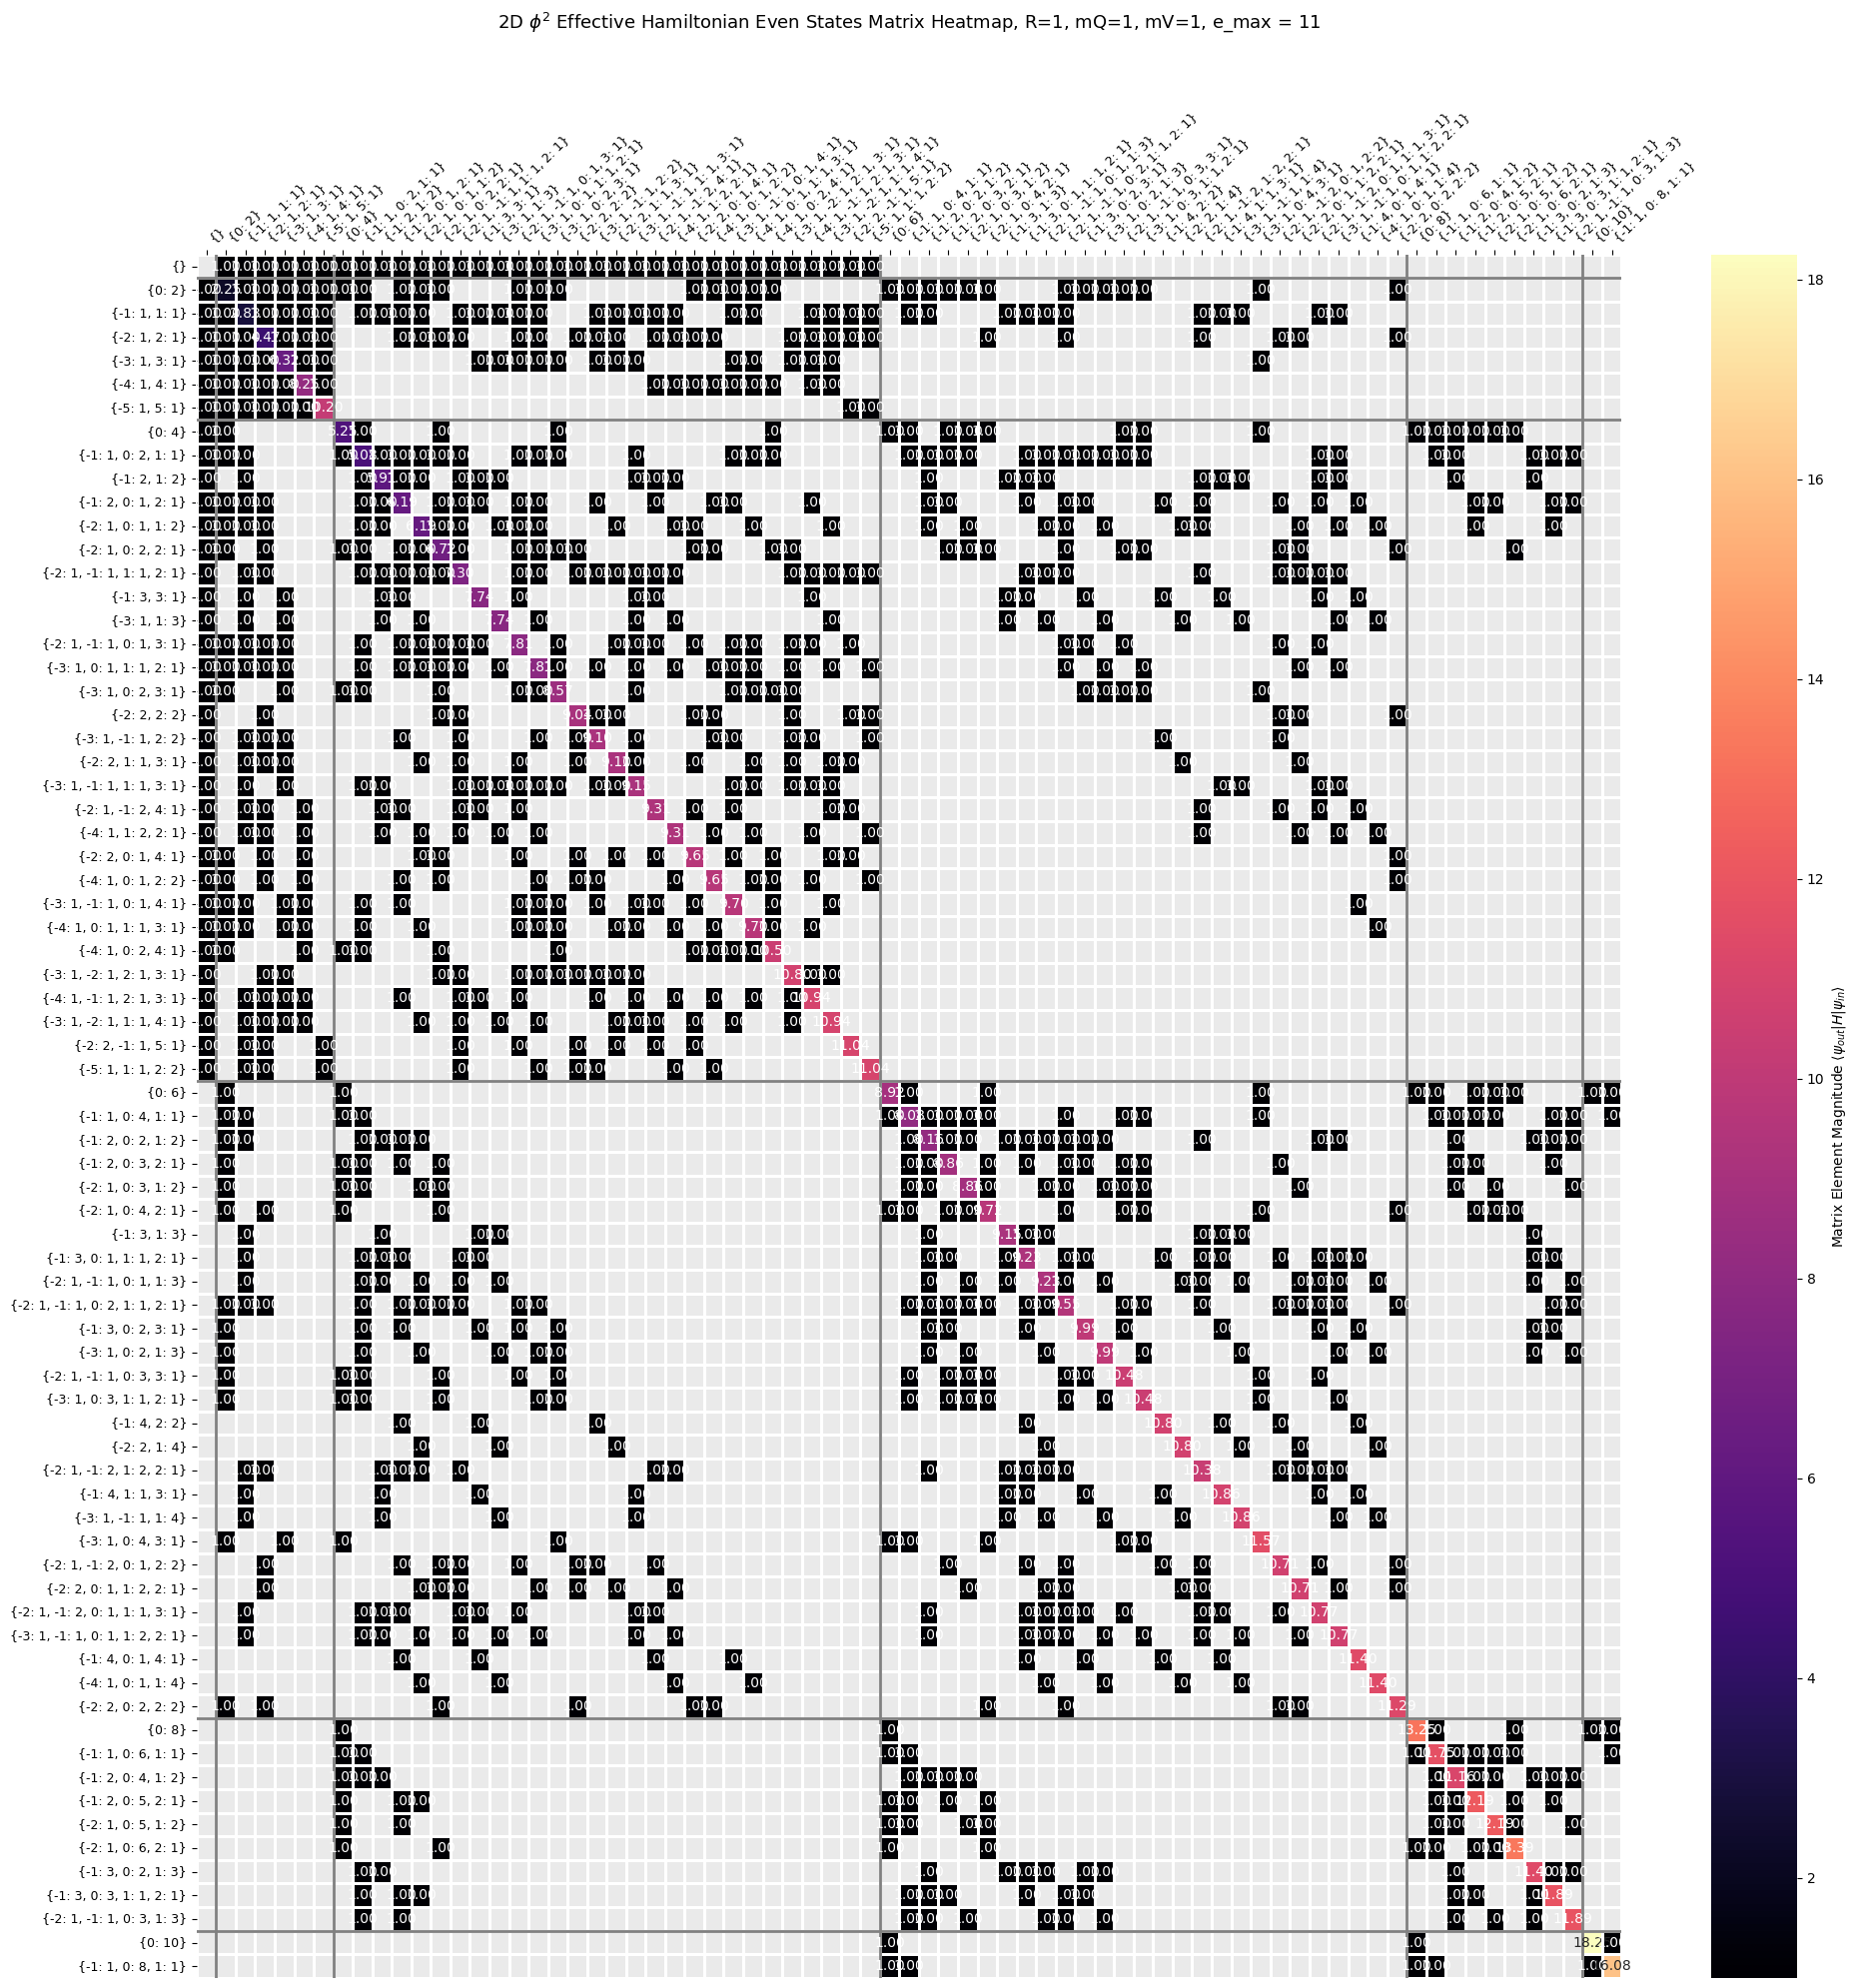

In [280]:
# --- Hamiltonian Parameters for Test ---
mV = 1; mQ=1; r = 1; e_max=11; lmaxeff = effective_lmax(e_max,e_max,mQ,r)


reduced_basis, asymList = basis_even(*gen_reduced_basis(lmaxeff,e_max,mQ,r)) #Select Even Basis States Only.
gen_omega_list(lmaxeff, mQ, r)

# 1. Compute properties.
occupation_numbers = np.array([get_total_occupation_number(state) for state in reduced_basis]) # State Occupation Number for each in basis.
state_energies = np.array([get_state_energy(state, mQ, r) for state in reduced_basis]) # State Energies for each in basis.

# 2. Sort the basis using lexsort, primarily by occupation number, secondly by energy.
sorted_indices = np.lexsort((state_energies, occupation_numbers)) 
sorted_basis = [reduced_basis[i] for i in sorted_indices]

# 2. a) Sort the list of asymmetric states.
inverted_map = np.argsort(sorted_indices)
sorted_asymList = inverted_map[asymList]

# 3. Identify unique occupation values and their starting indices
# (Using the sorted array guarantees these indices mark the boundaries)
unique_occ, boundaries_vec = np.unique(occupation_numbers[sorted_indices], return_index=True)

# 4. Map the boundaries to a dictionary
boundaries = dict(zip(unique_occ, boundaries_vec))


# Run the code to compute the transition matrix.
H_eff_coo=transition_matrix_phi4(mV, sorted_basis, state_energies[sorted_indices], boundaries, occupation_numbers[sorted_indices], sorted_asymList, lmaxeff)
#%timeit transition_matrix_phi4(mV, sorted_basis, state_energies[sorted_indices], boundaries, occupation_numbers[sorted_indices])

# Now buffing out the basis.
sorted_basis=convertBasis(sorted_basis, sorted_asymList)


# --- --- Plot --- ---

# --- State labels ---
verbose_labels = []
for state in sorted_basis:
    verbose_labels.append("{"+", ".join(f"{key}: {value}" for key, value in sorted(state.items()) if value !=0)+"}")

# --- Boundaries between occupation numbers for the plot ---
state_vecs = np.array([convert_state_to_list(state, lmaxeff) for state in sorted_basis])
boundaries = np.where(np.diff(np.sort(np.sum(state_vecs, axis=1))))[0]
boundaries[0] = 0

# --- Plotting the Heatmap Matrix ---
plt.figure(figsize=(20, 20))

zero_mask = (H_eff_coo.toarray() == 0.0) # So that we don't have an overcrowded plot.
ax = sns.heatmap(
    H_eff_coo.toarray(), 
    annot=True, 
    fmt=".2f", 
    cmap="magma", 
    linewidths=0.8,
    xticklabels=verbose_labels, 
    yticklabels=verbose_labels,
    mask=zero_mask,
    cbar_kws={'label': 'Matrix Element Magnitude $\\langle \\psi_{out} | H | \\psi_{in} \\rangle$'}
)

# Drawing separation dividers between states of differing occupation number.
for b in boundaries:
    ax.axvline(x=b+1, linewidth=2, color="grey")
    ax.axhline(y=b+1, linewidth=2, color="grey")


ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_facecolor('#eaeaea') # Soft gray for zero elements
plt.xticks(rotation=45, ha='left', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.title(rf"2D $\phi^2$ Effective Hamiltonian Even States Matrix Heatmap, R={r}, mQ={mQ}, mV={mV}, e_max = {e_max}", fontsize=13, pad=60)
plt.tight_layout()
plt.show()


## Timing Code to Compare with https://arxiv.org/abs/2110.08273

In [276]:
#Wrapper function to create the transition matrix for phi2
def wrapper_trma_phi4(e_max, mQ, mV, r):
     # Compute the effective lmax.
     lmaxeff = effective_lmax(e_max,e_max,mV,r)
     # Generate the basis and energy list (Not included in timings).
     basis, asymList = basis_even(*gen_reduced_basis(lmaxeff,emax,mQ,r))
     gen_omega_list(lmaxeff, mQ, r)

     # 1. Compute properties (occupation number and energy)
     occupation_numbers = np.array([get_total_occupation_number(state) for state in basis])
     state_energies = np.array([get_state_energy(state, mQ, r) for state in basis])

     # 2. Sort the basis using lexsort
     sorted_indices = np.lexsort((state_energies, occupation_numbers))
     sorted_basis = [basis[i] for i in sorted_indices]
    
     # 2. a) Sort the list of asymmetric states.
     inverted_map = np.argsort(sorted_indices)
     sorted_asymList = inverted_map[asymList]

     # 3. Identify unique occupation values and their starting indices
     # (Using the sorted array guarantees these indices mark the boundaries)
     unique_occ, boundaries_vec = np.unique(occupation_numbers[sorted_indices], return_index=True)

     # 4. Map the boundaries to a dictionary
     boundaries = dict(zip(unique_occ, boundaries_vec))

     # --- Run the transition matrix generation.
     return transition_matrix_phi4(mV, sorted_basis, state_energies[sorted_indices], boundaries, occupation_numbers[sorted_indices], sorted_asymList, lmaxeff)


E_max: 7
280 μs ± 12.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
E_max: 8
462 μs ± 3.51 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
E_max: 9
753 μs ± 6.62 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
E_max: 10
1.33 ms ± 6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
E_max: 11
2.34 ms ± 8.01 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
E_max: 12
3.85 ms ± 2 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
E_max: 13
6.71 ms ± 19.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
E_max: 14
11.2 ms ± 186 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


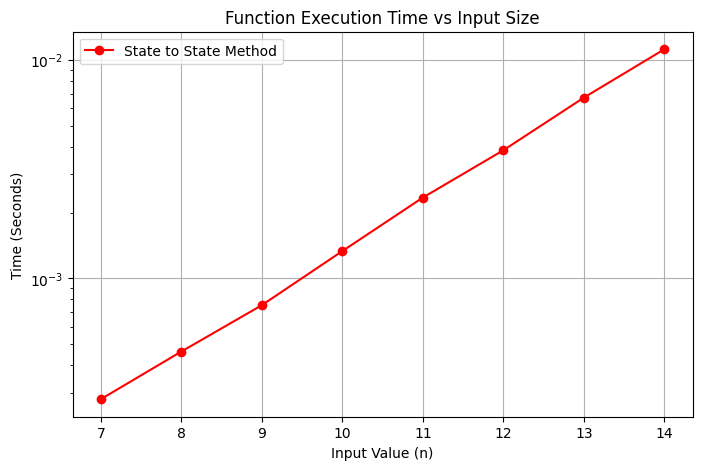

In [283]:
# 1. Preparing the parameters for the timing run, and lists for results.
m = 1; r = 1 # Hamiltonian parameters.
execution_times = []; basis_lengths = []
emax_list = range(7,15) #EMax range.

# 2. Run through emax list and time creation.
for emax in emax_list:
    print(f"E_max: {emax}")
    # Timing the transition matrix creation. The wrapper includes proper sorting of the basis.
    duration = %timeit -o wrapper_trma_phi4(emax, m, m, r)
    # Add results to relevant lists.
    execution_times.append(duration.average)
    basis_lengths.append(len(basis))


# 3. Export results to a CSV file
csv_filename = "statetostate_results.csv"
with open(csv_filename, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(f"mQ = {m}, mV = {m}, r = {r}")
    writer.writerow("EMax List")  # Writes emax list onto file header.
    writer.writerow(emax_list)
    writer.writerow(["Input Value", "Execution Time (Seconds)"])  # Headers
    writer.writerows(zip(emax_list,execution_times))

# 4. Plot the results
plt.figure(figsize=(8, 5))
plt.yscale('log')
plt.plot(emax_list, execution_times, marker='o', linestyle='-', color='r', label="State to State Method")
plt.title('Function Execution Time vs Input Size')
plt.xlabel('Input Value (n)')
plt.ylabel('Time (Seconds)')
plt.legend()
plt.grid(True)
plt.show()

### Graveyard

In [ ]:
# NOTE Input states and energies MUST first be sorted by occupation number, followed by energy.
def transition_matrix_phi4(g, sorted_basis, sorted_energies, boundaries, occupation_numbers):
    


    # phi2 Coupling
    cphi4=g/24

    # --- Now iterating over all zero or two Hamming Distance states. ---
    H_eff = []; cols = []; rows = []
    
    # This dictionary is to keep track of how many times a state of momentum l has been removed from a block of given occupation number.
    running_iy2=Counter({0:0})
    running_iypm2=Counter({(0,0):0})
    running_iy4=Counter({0:0})


    
    # Selecting states with occupation number 4:
    remov4_states = sorted_basis[boundaries[4]:boundaries[6]]
    remov2_states = sorted_basis[boundaries[2]:boundaries[4]]
    
    # Iterate over states
    for ix, state in enumerate(sorted_basis):
        # Ignore the zero state.
        if ix>0:
            # --- Zero Difference in Occupation Number ---
            
            # Hit the Diagonal. First with the \phi^2 operator, then with the state energy.
            H_eff.extend([(cphi4) * phi4_hd0(state) + sorted_energies[ix]])
            rows.extend([ix]); cols.extend([ix])
            
            
            if occupation_numbers[ix]>=2: # Need at least two states to remove.

                # --- Two Difference in Occupation Number ---

                # First calculating result from removing & adding each state:
                _tempaddremove = {ll: nll * 1/ omega_list[ll] for ll, nll, in state.items()}
                # This allows us to jump to the next boundary when the current state has two more occupants than the previous state.
                lower_bound = boundaries[occupation_numbers[ix]-2]
                
                # Iterate over all possible angular momenta, so that we can check if it is possible to remove from them.
                for l,nl in state.items():
                    
                    # ---- Raise 1 low 3 operations ----
                    # Remove twice from the l=0 state.
                    if l==0 and state[l]>=2:
                        
                        # Calculates the y-index of the new state.
                        iy = max(lower_bound,running_iy2[0])
                        # Transition matrix element by the formula in section 3.3 of the draft.
                        res = (cphi4) * math.sqrt(nl*(nl-1)) * (1/omega_list[0]) * sum([_tempaddremove[ll] if ll!=0 else math.sqrt((nll-2)*(nll-1)) * (1/omega_list[0]) for ll, nll in state.items()])

                        # Adds to H_eff both the transition matrix element for removing and adding l=0.
                        H_eff.extend([res, res])
                        
                        cols.extend([ix, iy]); rows.extend([iy, ix])
                        
                        # Increases the running dictionary so that we can keep track of the next created state index.
                        running_iy2[0] = iy + 1
                        
                    elif l>0 and state[-l]!=0:
                        iy = max(lower_bound,running_iy2[l])
                        
                        # Calculating the transition matrix element by the formula in section 3.3 of the draft.
                        res = 2 * cphi4 * math.sqrt(nl*state[-l]) / (omega_list[abs(l)]) * sum([_tempaddremove[ll] if ll!=l else math.sqrt((nll-2)*(nll-1)) * (1/omega_list[abs(ll)]) for ll, nll in state.items()])

                        
                        # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).
                        H_eff.extend([res, res])
                        cols.extend([ix, iy]); rows.extend([iy, ix])
                        
                        # Increases the running dictionary so that we can keep track of the next created state index.
                        running_iy2[l] = iy + 1
                    

                # --- Zero Difference in Occupation Number ---
                # ---- 2 raising 2 lowering operations ----

                lower_bound = boundaries[occupation_numbers[ix]]


                print(f'--------- New State ---------')

                for rem_ix, rem_state in enumerate(remov2_states):
                    # Calculates the y-index of the new state.
                    
                    # Checking if we can remove rem_state.
                    print(f'rem_state = {rem_state}, state={state}')

                    
                    diff = state.copy()
                    diff.subtract(rem_state)
                    if all(delta_nl>=0 for _,delta_nl in diff.items()):

                        result = cphi4
                        for rl, rnl in rem_state.items():
                            result = result * np.sqrt(falling_factorial(nl,rnl)/omega_list[rl]**rnl)
                        
                        for add_ix, add_state in enumerate(remov2_states):
                            if add_ix < rem_ix: # Ensures only smaller energy states added back on.
                                # Now calculating the y index.
                                #print(f'lower_bound={lower_bound}, iy = {iy}, ix = {ix}')
                                iy = max(lower_bound, running_iypm2[(rem_ix)])
                                #print(f'lower_bound={lower_bound}, iy = {iy},  ix = {ix}')
                                #print(f'Original State = {state}, Removed State = {rem_state},Added State = {add_state}')

                                res = result
                                for al, anl in add_state.items():
                                    res = res * np.sqrt(raising_factorial(nl,anl)/omega_list[al]**anl)

                                # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).
                                H_eff.extend([res, res])
                                cols.extend([ix, iy]); rows.extend([iy, ix])

                                running_iypm2[(rem_ix)] = iy + 1
                        print(running_iypm2)


                for addrem_ix, addrem_state in enumerate(remov4_states):
                    if addrem_state 
                    # Now splitting this state in half.
                    
                    # Checking if we can remove rem_state.
                    print(f'rem_state = {rem_state}, state={state}')

                    
                    diff = state.copy()
                    diff.subtract(rem_state)
                    rem_state = 
                    add_state = 
                    if all(delta_nl>=0 for delta_l,delta_nl in diff.items() if delta_l < 0):

                        result = cphi4
                        for rl, rnl in rem_state.items():
                            if rl > 0:
                                result = result * np.sqrt(falling_factorial(nl,rnl)/omega_list[rl]**rnl)
                        
                        for add_ix, add_state in enumerate(remov2_states):
                            if add_ix < rem_ix: # Ensures only smaller energy states added back on.
                                # Now calculating the y index.
                                #print(f'lower_bound={lower_bound}, iy = {iy}, ix = {ix}')
                                iy = max(lower_bound, running_iypm2[(rem_ix)])
                                #print(f'lower_bound={lower_bound}, iy = {iy},  ix = {ix}')
                                #print(f'Original State = {state}, Removed State = {rem_state},Added State = {add_state}')

                                res = result
                                for al, anl in add_state.items():
                                    res = res * np.sqrt(raising_factorial(nl,anl)/omega_list[al]**anl)

                                # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).
                                H_eff.extend([res, res])
                                cols.extend([ix, iy]); rows.extend([iy, ix])

                                running_iypm2[(rem_ix)] = iy + 1
                        print(running_iypm2)



                # ---- 4 lowering operations ----

                if occupation_numbers[ix]>=4:
                    lower_bound = boundaries[occupation_numbers[ix]-4]
                    
                    for rem_ix, rem_state in enumerate(remov4_states):
                        if all(delta_nl>=0 for delta_nl in (state-rem_state).values()):
                            result = cphi4
                            for rl, rnl in rem_state.items():
                                result = result * np.sqrt(falling_factorial(nl,rnl)/omega_list[rl]**rnl)
                            
                            # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).
                            H_eff.extend([result, result])
                            cols.extend([ix, iy]); rows.extend([iy, ix])

                            running_iy4[rem_ix] = iy + 1
            
    # Convert to sparse matrix format.
    H_eff = np.array(H_eff); rows = np.array(rows); cols = np.array(cols)

    return sp.coo_matrix((H_eff,(rows, cols)), shape=(len(sorted_basis),len(sorted_basis)))